# 07 — Customer Churn Prediction
Train Logistic Regression, Random Forest, Gradient Boosting; evaluate AUC-ROC, feature importance.

**Input:** `data/featured/model_ready.csv`

In [1]:
import os
import sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

from src.modeling import run_training_pipeline, get_best_model_name, get_feature_importances
from src.visualizations import plot_roc_curves, plot_confusion_matrices, plot_feature_importance
import pandas as pd

results, best_model, scaler = run_training_pipeline(
    data_path='data/featured/model_ready.csv',
    model_dir='model',
    save_all_models=True
)

Best model (Logistic Regression) saved to model/best_model.pkl
Scaler saved to model/scaler.pkl
Saved Logistic Regression to model/logistic_regression.pkl
Saved Random Forest to model/random_forest.pkl
Saved Gradient Boosting to model/gradient_boosting.pkl


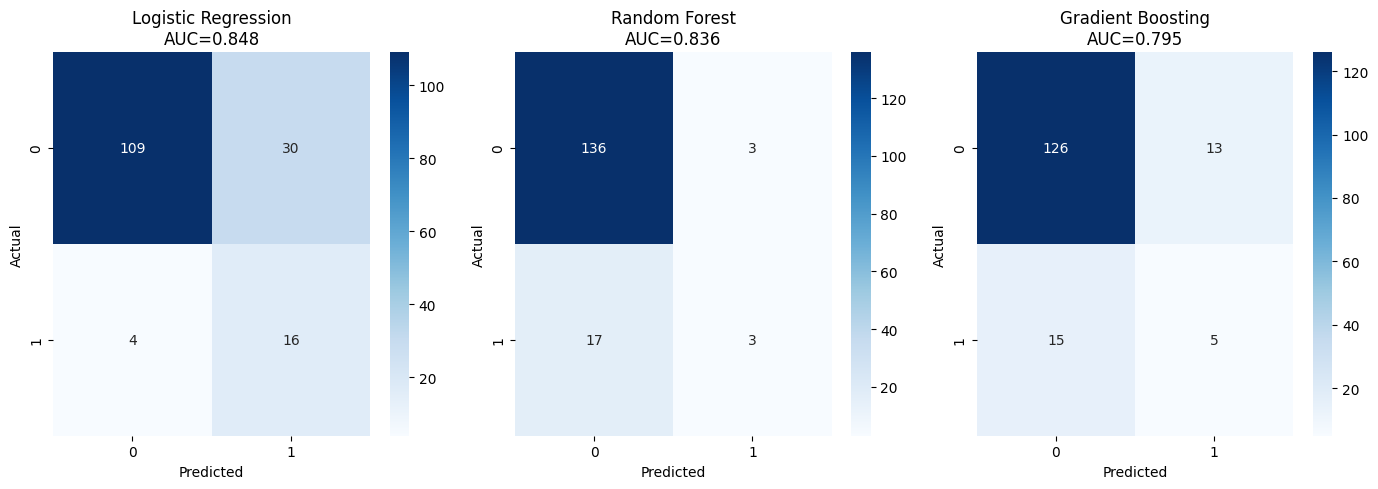

In [2]:
df = pd.read_csv('data/featured/model_ready.csv')
from src.modeling import prepare_train_test
X_train, X_test, y_train, y_test = prepare_train_test(df)

os.makedirs('images/eda_charts', exist_ok=True)
plot_roc_curves(results, y_test, save_path='images/eda_charts/roc_comparison.png')
plot_confusion_matrices(results, y_test, save_path='images/eda_charts/confusion_matrices.png')

In [3]:
best_name = get_best_model_name(results)
if hasattr(best_model, 'feature_importances_'):
    imp = get_feature_importances(best_model, X_train.columns)
    plot_feature_importance(imp, save_path='images/eda_charts/feature_importance.png')
    print('Top 10 churn predictors:'); print(imp.head(10))